In [4]:
import matplotlib.pyplot as plt
import pandas as pd

In [5]:
df = pd.read_csv("../data/processed/customerIQ_customer_churn_features.csv")
df.head()

,customer_id,age,gender,location,tenure_months,monthly_spend,total_spend,login_frequency,support_tickets,product_usage,subscription_type,payment_method,discount_used,churn,customer_lifetime_value,average_monthly_spend,usage_per_month,support_ticket_rate,age_group,tenure_group
0,C100000,56.0,Female,Mumbai,40,1008.23,43296.89,20.0,1,68.0,Monthly,Debit Card,1,0,45804.53,1082.422250,1.700000,0.025000,51+,25+ months
1,C100001,69.0,Male,Delhi,31,1716.53,52968.01,20.0,3,87.0,Monthly,UPI,0,0,92328.73,1708.645484,2.806452,0.096774,51+,25+ months
2,C100002,46.0,Female,Mumbai,65,1035.82,72203.52,23.0,7,88.0,Monthly,Wallet,1,0,83848.62,1110.823385,1.353846,0.107692,36-50,25+ months
3,C100003,32.0,Male,Other,39,2622.21,107971.82,13.0,1,68.0,Annual,UPI,0,0,126076.33,2768.508205,1.743590,0.025641,26-35,25+ months
4,C100004,60.0,Male,Pune,24,2117.73,49767.32,4.0,2,80.0,Monthly,Debit Card,1,0,72619.73,2073.638333,3.333333,0.083333,51+,13-24 months


In [6]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
print(df.columns.tolist())

Rows: 10000
Columns: 20
['customer_id', 'age', 'gender', 'location', 'tenure_months', 'monthly_spend', 'total_spend', 'login_frequency', 'support_tickets', 'product_usage', 'subscription_type', 'payment_method', 'discount_used', 'churn', 'customer_lifetime_value', 'average_monthly_spend', 'usage_per_month', 'support_ticket_rate', 'age_group', 'tenure_group']


In [7]:
classification_results = pd.read_csv("../data/processed/classification_results.csv")
regression_results = pd.read_csv("../data/processed/regression_results.csv")
final_model_summary = pd.read_csv("../data/processed/final_model_summary.csv")

In [8]:
final_model_summary

,Task,Best Model,Main Metric,Score
0,Churn Prediction,Logistic Regression,F1 Score,0.088550
1,CLV Prediction,Linear Regression,R2,0.967371


In [9]:
churn_rate = df["churn"].mean() * 100

print("Overall Churn Rate:", round(churn_rate, 2), "%")

Overall Churn Rate: 2.57 %


In [10]:
churn_counts = df["churn"].value_counts()

print("Retained Customers:", churn_counts.get(0, 0))
print("Churned Customers:", churn_counts.get(1, 0))

Retained Customers: 9743
Churned Customers: 257


In [11]:
subscription_churn = df.groupby("subscription_type")["churn"].mean().mul(100).sort_values(ascending=False)

subscription_churn

subscription_type
Quarterly    3.081664
Monthly      2.713459
Annual       1.861386
Name: churn, dtype: float64

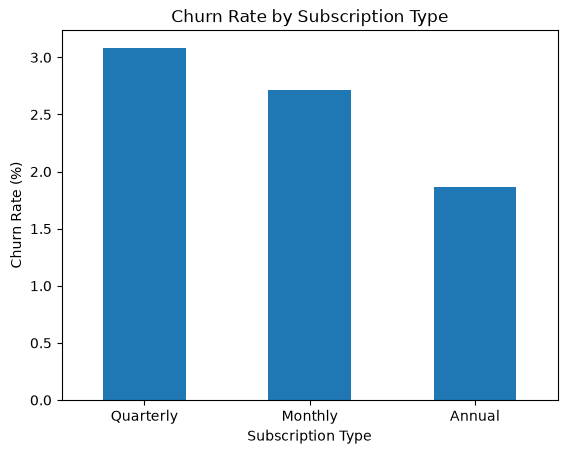

In [12]:
subscription_churn.plot(kind="bar")

plt.ylabel("Churn Rate (%)")
plt.xlabel("Subscription Type")
plt.title("Churn Rate by Subscription Type")
plt.xticks(rotation=0)
plt.show()

In [13]:
tenure_churn = df.groupby("tenure_group")["churn"].mean().mul(100).sort_values(ascending=False)

tenure_churn

tenure_group
0-6 months      5.813953
7-12 months     3.896104
13-24 months    3.600248
25+ months      1.736007
Name: churn, dtype: float64

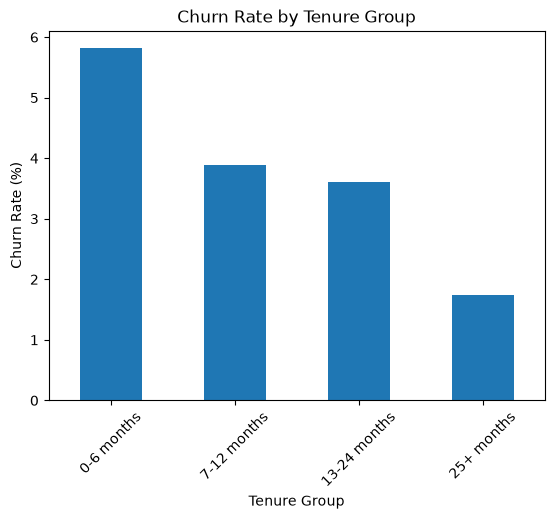

In [14]:
tenure_churn.plot(kind="bar")

plt.ylabel("Churn Rate (%)")
plt.xlabel("Tenure Group")
plt.title("Churn Rate by Tenure Group")
plt.xticks(rotation=45)
plt.show()

In [15]:
behavior_comparison = df.groupby("churn")[
    ["monthly_spend", "login_frequency", "product_usage", "support_tickets"]
].mean()

behavior_comparison

,monthly_spend,login_frequency,product_usage,support_tickets
churn,,,,
0,1863.895031,14.900339,71.374731,2.243662
1,1898.750603,13.447471,61.342412,2.797665


In [16]:
clv_by_subscription = df.groupby("subscription_type")[
    "customer_lifetime_value"
].mean().sort_values(ascending=False)

clv_by_subscription

subscription_type
Annual       99667.284083
Quarterly    91409.874869
Monthly      90128.887918
Name: customer_lifetime_value, dtype: float64

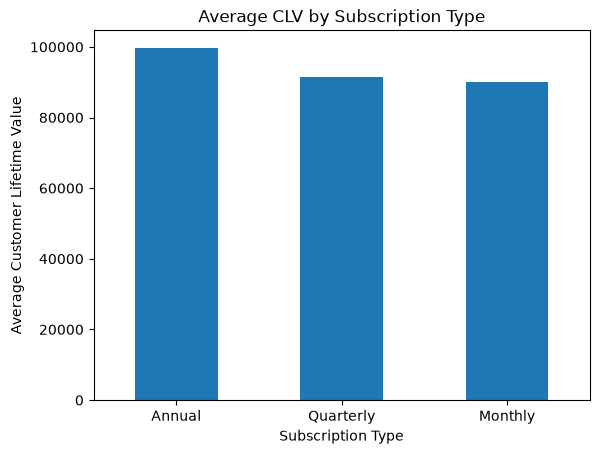

In [17]:
clv_by_subscription.plot(kind="bar")

plt.ylabel("Average Customer Lifetime Value")
plt.xlabel("Subscription Type")
plt.title("Average CLV by Subscription Type")
plt.xticks(rotation=0)
plt.show()

In [18]:
clv_by_tenure = df.groupby("tenure_group")[
    "customer_lifetime_value"
].mean().sort_values(ascending=False)

clv_by_tenure

tenure_group
25+ months      109400.831857
13-24 months     68231.691688
7-12 months      54815.605702
0-6 months       47094.161953
Name: customer_lifetime_value, dtype: float64

In [19]:
highest_churn_subscription = subscription_churn.idxmax()
highest_churn_rate = subscription_churn.max()

highest_clv_subscription = clv_by_subscription.idxmax()
highest_clv_value = clv_by_subscription.max()

highest_churn_tenure = tenure_churn.idxmax()
highest_churn_tenure_rate = tenure_churn.max()

highest_clv_tenure = clv_by_tenure.idxmax()
highest_clv_tenure_value = clv_by_tenure.max()

print("BUSINESS INSIGHTS")
print()
print("Highest churn subscription type:", highest_churn_subscription)
print("Highest churn rate:", round(highest_churn_rate, 2), "%")
print()
print("Highest CLV subscription type:", highest_clv_subscription)
print("Highest average CLV:", round(highest_clv_value, 2))
print()
print("Highest churn tenure group:", highest_churn_tenure)
print("Highest churn rate for tenure group:", round(highest_churn_tenure_rate, 2), "%")
print()
print("Highest CLV tenure group:", highest_clv_tenure)
print("Highest average CLV for tenure group:", round(highest_clv_tenure_value, 2))

BUSINESS INSIGHTS

Highest churn subscription type: Quarterly
Highest churn rate: 3.08 %

Highest CLV subscription type: Annual
Highest average CLV: 99667.28

Highest churn tenure group: 0-6 months
Highest churn rate for tenure group: 5.81 %

Highest CLV tenure group: 25+ months
Highest average CLV for tenure group: 109400.83
